This notebook demonstrates a maze game based on Q-learning.  
本 Notebook 展示了一个基于 Q-learning 的迷宫游戏。

In [13]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

## Maze Environment / 迷宫环境
This class defines the maze environment, including state space, action space, and reward function.  
这个类定义了迷宫环境，包括状态空间、动作空间和奖励函数。

In [14]:
GRID_SIZE = 6  # Maze size

def is_reachable(grid, start, goal):
    """
    Use BFS to check if start and goal are connected
    使用 BFS 检查起点和终点是否连通
    """
    visited = set()
    queue = deque([start])
    while queue:
        r, c = queue.popleft()
        if (r, c) == goal:
            return True
        for dr, dc in [(0,1),(0,-1),(1,0),(-1,0)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE and grid[nr][nc] != -1 and (nr,nc) not in visited:
                visited.add((nr,nc))
                queue.append((nr,nc))
    return False

class MazeEnv:
    def __init__(self):
        """
        Initialize maze environment:
        - Randomly generate walls
        - Ensure start and goal are connected
        初始化迷宫环境：
        - 随机生成墙壁
        - 保证起点和终点连通
        """
        while True:
            self.grid = np.zeros((GRID_SIZE, GRID_SIZE))
            for _ in range(GRID_SIZE):
                r, c = random.randint(0, GRID_SIZE-1), random.randint(0, GRID_SIZE-1)
                self.grid[r][c] = -1
            self.start = (0,0)
            self.goal = (GRID_SIZE-1, GRID_SIZE-1)
            self.grid[self.start] = 0
            self.grid[self.goal] = 0
            if is_reachable(self.grid, self.start, self.goal):
                break
        self.state = self.start

    def reset(self):
        """Reset environment and return start state"""
        self.state = self.start
        return self.state

    def step(self, action):
        """
        Execute action:
        0 = up, 1 = down, 2 = left, 3 = right
        """
        r, c = self.state
        if action == 0: r -= 1
        elif action == 1: r += 1
        elif action == 2: c -= 1
        elif action == 3: c += 1

        # Hit wall or out of bounds
        if r < 0 or r >= GRID_SIZE or c < 0 or c >= GRID_SIZE or self.grid[r][c] == -1:
            return self.state, -5, False

        self.state = (r, c)

        # Reach goal
        if self.state == self.goal:
            return self.state, 10, True

        return self.state, -1, False

## Q-learning Agent / Q-learning 智能体
This class defines the agent, including Q-table, epsilon-greedy strategy, and update formula.  
这个类定义了智能体，包括 Q-table、epsilon-greedy 策略和更新公式。

In [15]:
ALPHA = 0.1   # Learning rate / 学习率
GAMMA = 0.9   # Discount factor / 折扣因子
EPSILON = 0.2 # Exploration rate / 探索率

class QAgent:
    def __init__(self):
        # Initialize Q-table
        self.q_table = np.zeros((GRID_SIZE, GRID_SIZE, 4))
        self.EPSILON = EPSILON

    def choose_action(self, state):
        """
        epsilon-greedy strategy:
        - With probability EPSILON, choose random action (exploration)
        - Otherwise choose action with max Q-value (exploitation)
        epsilon-greedy 策略：
        - 以 EPSILON 概率随机选择动作（探索）
        - 否则选择 Q-table 中的最大值动作（利用）
        """
        if random.uniform(0,1) < self.EPSILON:
            return random.randint(0,3)
        r, c = state
        return np.argmax(self.q_table[r][c])

    def learn(self, state, action, reward, next_state):
        """
        Q-learning update formula:
        Q(s,a) ← Q(s,a) + α [r + γ max Q(s’,a’) - Q(s,a)]
        Q-learning 更新公式：
        Q(s,a) ← Q(s,a) + α [r + γ max Q(s’,a’) - Q(s,a)]
        """
        r, c = state
        nr, nc = next_state
        predict = self.q_table[r][c][action]
        target = reward + GAMMA * np.max(self.q_table[nr][nc])
        self.q_table[r][c][action] += ALPHA * (target - predict)

## Training / 训练过程
We train the agent using Q-learning for multiple episodes and plot the cumulative reward curve.  
我们使用 Q-learning 算法训练智能体多个回合，并绘制累计奖励曲线。

In [16]:
EPISODES = 500  # Number of training episodes

def train(env, agent):
    rewards_per_episode = []
    for ep in range(EPISODES):
        state = env.reset()
        done = False
        total_reward = 0
        while not done:
            # Choose action using epsilon-greedy strategy
            action = agent.choose_action(state)
            # Execute action and get next state and reward
            next_state, reward, done = env.step(action)
            # Update Q-table using Q-learning formula
            agent.learn(state, action, reward, next_state)
            state = next_state
            total_reward += reward
        rewards_per_episode.append(total_reward)

    # Plot training curve to observe convergence
    plt.plot(rewards_per_episode)
    plt.xlabel("Episode")
    plt.ylabel("Cumulative Reward")
    plt.title("Training Progress")
    plt.show()
    return agent

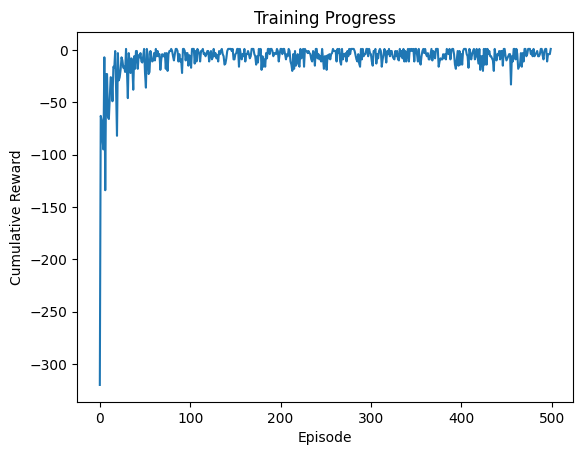

In [17]:
env = MazeEnv()
agent = QAgent()
agent = train(env, agent)

## Demonstration / 演示
Colab does not support Pygame window.  
Here we use Matplotlib to visualize the agent's path in the maze.  
Colab 不支持 Pygame 窗口。  
这里我们用 Matplotlib 绘制智能体在迷宫中的路径。

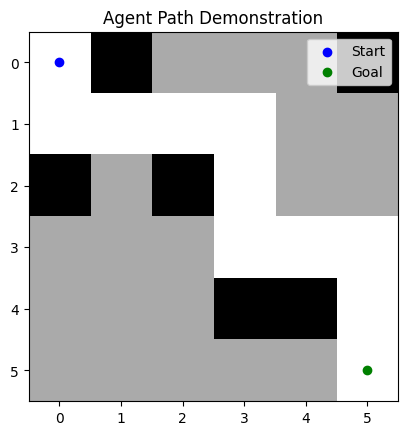

In [18]:
state = env.reset()
path = [state]
done = False
steps = 0
max_steps = 50
agent.EPSILON = 0  # Use optimal policy during demonstration

while not done and steps < max_steps:
    action = agent.choose_action(state)
    next_state, reward, done = env.step(action)
    state = next_state
    path.append(state)
    steps += 1

# Draw path using Matplotlib
grid_display = env.grid.copy()
for r,c in path:
    grid_display[r][c] = 0.5
plt.imshow(grid_display, cmap="gray")
plt.scatter(env.start[1], env.start[0], c="blue", label="Start")
plt.scatter(env.goal[1], env.goal[0], c="green", label="Goal")
plt.legend()
plt.title("Agent Path Demonstration")
plt.show()